
### Rank stocks by 1M · 3M · 6M · 1Y returns

**Author:** Kishore | PGDM Finance, TSM Madurai  
**Tools:** Python · yfinance · pandas · matplotlib · seaborn

---

**What this notebook covers:**
1. Download price data for all 50 Nifty stocks automatically
2. Calculate 1M, 3M, 6M, 1Y returns for every stock
3. Rank stocks on each timeframe — find the leaders and laggards
4. Build a composite momentum score combining all timeframes
5. Visualise top and bottom performers
6. Identify momentum clusters by sector
7. Export a clean screener table you can show at

> **CV Note:** *"Built a Python-based momentum screener ranking all Nifty 50 stocks by 1M, 3M, 6M, and 1Y returns with composite scoring and sector heatmap analysis using Python"*

---

### 📚 What is Momentum?

> **Momentum** is the tendency of stocks that have performed well recently to continue outperforming — and stocks that have underperformed to continue lagging.  
> It is one of the most well-documented and widely used factors in equity investing globally.  
> Momentum strategies are used by mutual funds, hedge funds, and prop desks at firms like .

| Timeframe | Why it matters |
|-----------|----------------|
| 1 Month   | Short-term trend — recent news, earnings, sector rotation |
| 3 Months  | Medium-term trend — sector cycle, quarterly earnings impact |
| 6 Months  | Intermediate trend — most commonly used by fund managers |
| 1 Year    | Long-term trend — business cycle, structural story |

---
## 🔧 Section 0 — Install & Import Libraries

In [8]:
!pip install yfinance --quiet

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

print('✅ Libraries loaded')

✅ Libraries loaded


---
## 📌 Section 1 — Define Nifty 50 Universe

> All 50 Nifty stocks with their sector classification.  
> You can customise this list — add/remove tickers as needed.

In [21]:
# ── Full Nifty 50 Universe with Sectors ───────────────────────────────────────

NIFTY50 = {
    # Banking & Finance
    'HDFCBANK':   ('HDFCBANK.NS',   'Banking'),
    'ICICIBANK':  ('ICICIBANK.NS',  'Banking'),
    'KOTAKBANK':  ('KOTAKBANK.NS',  'Banking'),
    'AXISBANK':   ('AXISBANK.NS',   'Banking'),
    'SBIN':       ('SBIN.NS',       'Banking'),
    'BAJFINANCE': ('BAJFINANCE.NS', 'Finance'),
    'BAJAJFINSV': ('BAJAJFINSV.NS', 'Finance'),
    'HDFCLIFE':   ('HDFCLIFE.NS',   'Insurance'),
    'SBILIFE':    ('SBILIFE.NS',    'Insurance'),

    # IT
    'TCS':        ('TCS.NS',        'IT'),
    'INFY':       ('INFY.NS',       'IT'),
    'WIPRO':      ('WIPRO.NS',      'IT'),
    'HCLTECH':    ('HCLTECH.NS',    'IT'),
    'TECHM':      ('TECHM.NS',      'IT'),

    # Energy & Oil
    'RELIANCE':   ('RELIANCE.NS',   'Energy'),
    'ONGC':       ('ONGC.NS',       'Energy'),
    'POWERGRID':  ('POWERGRID.NS',  'Energy'),
    'NTPC':       ('NTPC.NS',       'Energy'),
    'BPCL':       ('BPCL.NS',       'Energy'),
    'COALINDIA':  ('COALINDIA.NS',  'Energy'),

    # Auto
    'MARUTI':     ('MARUTI.NS',     'Auto'),
    'TATAMOTORS': ('TATAMOTORS.NS', 'Auto'),
    'M&M':        ('M&M.NS',        'Auto'),
    'EICHERMOT':  ('EICHERMOT.NS',  'Auto'),
    'HEROMOTOCO': ('HEROMOTOCO.NS', 'Auto'),

    # FMCG
    'HINDUNILVR': ('HINDUNILVR.NS', 'FMCG'),
    'ITC':        ('ITC.NS',        'FMCG'),
    'NESTLEIND':  ('NESTLEIND.NS',  'FMCG'),
    'BRITANNIA':  ('BRITANNIA.NS',  'FMCG'),

    # Pharma
    'SUNPHARMA':  ('SUNPHARMA.NS',  'Pharma'),
    'DRREDDY':    ('DRREDDY.NS',    'Pharma'),
    'CIPLA':      ('CIPLA.NS',      'Pharma'),
    'DIVISLAB':   ('DIVISLAB.NS',   'Pharma'),

    # Metals & Mining
    'TATASTEEL':  ('TATASTEEL.NS',  'Metals'),
    'JSWSTEEL':   ('JSWSTEEL.NS',   'Metals'),
    'HINDALCO':   ('HINDALCO.NS',   'Metals'),

    # Industrials & Infra
    'LT':         ('LT.NS',         'Industrials'),
    'ADANIPORTS': ('ADANIPORTS.NS', 'Industrials'),
    'ULTRACEMCO': ('ULTRACEMCO.NS', 'Industrials'),
    'GRASIM':     ('GRASIM.NS',     'Industrials'),
    'SHREECEM':   ('SHREECEM.NS',   'Industrials'),

    # Consumer
    'ASIANPAINT': ('ASIANPAINT.NS', 'Consumer'),
    'TITAN':      ('TITAN.NS',      'Consumer'),
    'TATACONSUM': ('TATACONSUM.NS', 'Consumer'),

    # Telecom
    'BHARTIARTL': ('BHARTIARTL.NS', 'Telecom'),

    # Conglomerate / Others
    'INDUSINDBK': ('INDUSINDBK.NS', 'Banking'),
    'APOLLOHOSP': ('APOLLOHOSP.NS', 'Healthcare'),
    'ADANIENT':   ('ADANIENT.NS',   'Conglomerate'),
    'TATAPOWER':  ('TATAPOWER.NS',  'Energy'),
    'VEDL':       ('VEDL.NS',       'Metals'),
}

tickers_list = [v[0] for v in NIFTY50.values()]
names_list   = list(NIFTY50.keys())
sector_map   = {k: v[1] for k, v in NIFTY50.items()}

print(f'Universe : {len(NIFTY50)} Nifty stocks across {len(set(sector_map.values()))} sectors')
print(f'Sectors  : {", ".join(sorted(set(sector_map.values())))}')

Universe : 50 Nifty stocks across 14 sectors
Sectors  : Auto, Banking, Conglomerate, Consumer, Energy, FMCG, Finance, Healthcare, IT, Industrials, Insurance, Metals, Pharma, Telecom


---
## 📥 Section 2 — Download 1-Year Price Data

In [11]:
print('Downloading 1-year price data for all Nifty 50 stocks...')
print('This may take 30-60 seconds...\n')

raw = yf.download(tickers_list, period='1y', auto_adjust=True, progress=False)
close = raw['Close'].copy()

# Rename columns from ticker symbols back to short names
ticker_to_name = {v[0]: k for k, v in NIFTY50.items()}
close.columns = [ticker_to_name.get(col, col) for col in close.columns]
close.dropna(how='all', inplace=True)

# Also download Nifty 50 benchmark
nifty = yf.download('^NSEI', period='1y', auto_adjust=True, progress=False)['Close']
nifty.dropna(inplace=True)

print(f'✅ Data downloaded')
print(f'   Period : {close.index[0].date()} → {close.index[-1].date()}')
print(f'   Stocks : {close.shape[1]} stocks | {close.shape[0]} trading days')
print(f'\nStocks with complete data: {close.notna().all().sum()}')
print(f'Stocks with partial data : {(~close.notna().all()).sum()}')

This may take 30-60 seconds...



ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFPricesMissingError('possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")')


✅ Data downloaded
   Period : 2025-05-07 → 2026-05-07
   Stocks : 50 stocks | 250 trading days

Stocks with complete data: 45
Stocks with partial data : 5


---
## 📐 Section 3 — Calculate Momentum Returns

> **How returns are calculated:**  
> For each timeframe, we compare today's price to the price N trading days ago.  
> - 1M ≈ 21 trading days  
> - 3M ≈ 63 trading days  
> - 6M ≈ 126 trading days  
> - 1Y ≈ 252 trading days

In [12]:
WINDOWS = {
    '1M':  21,
    '3M':  63,
    '6M':  126,
    '1Y':  252,
}

returns_df = pd.DataFrame(index=close.columns)
returns_df.index.name = 'Stock'

for label, days in WINDOWS.items():
    for stock in close.columns:
        prices = close[stock].dropna()

        # Ensure there are enough data points to calculate a return
        if len(prices) < 2:
            returns_df.loc[stock, label] = np.nan
            continue

        if len(prices) >= days:
            ret = (prices.iloc[-1] / prices.iloc[-days] - 1) * 100
        else:
            # Use available data if full window is not present
            ret = (prices.iloc[-1] / prices.iloc[0] - 1) * 100
        returns_df.loc[stock, label] = round(ret, 2)

# Add sector
returns_df['Sector'] = returns_df.index.map(sector_map)

# Current price
returns_df['Price'] = close.iloc[-1].round(2)

# Drop stocks with all NaN returns
returns_df.dropna(subset=['1M', '3M', '6M', '1Y'], how='all', inplace=True)

print('Returns calculated:')
print('=' * 65)
print(f'{"Stock":<14} {"1M":>8} {"3M":>8} {"6M":>8} {"1Y":>8}  {"Sector"}')
print('-' * 65)
for stock, row in returns_df.iterrows():
    print(f'{stock:<14} {row["1M"]:>7.1f}% {row["3M"]:>7.1f}% {row["6M"]:>7.1f}% {row["1Y"]:>7.1f}%  {row["Sector"]}')
print('=' * 65)


Returns calculated:
Stock                1M       3M       6M       1Y  Sector
-----------------------------------------------------------------
ADANIENT          23.7%    14.8%     2.5%     7.5%  Conglomerate
ADANIPORTS        18.9%    12.9%    19.7%    29.8%  Industrials
APOLLOHOSP         5.5%    10.3%    -0.1%    12.1%  Healthcare
ASIANPAINT        10.4%     3.9%     0.5%     9.1%  Consumer
AXISBANK          -2.8%    -4.4%     5.1%    11.7%  Banking
BAJAJFINSV         8.3%    -5.5%   -12.7%   -10.1%  Finance
BAJFINANCE         6.3%     0.9%    -6.8%     8.9%  Finance
BHARTIARTL        -1.7%    -8.4%   -11.8%    -2.7%  Telecom
BPCL               2.8%   -17.9%   -12.4%     3.1%  Energy
BRITANNIA          4.8%    -1.4%    -0.5%     9.9%  FMCG
CIPLA             12.7%     3.6%    -9.3%    -8.2%  Pharma
COALINDIA          4.2%    10.4%    25.4%    30.7%  Energy
DIVISLAB          15.1%    13.1%    -0.1%    10.0%  Pharma
DRREDDY            9.4%     5.5%     8.9%    13.0%  Pharma
EICHERMOT 

---
## 🏆 Section 4 — Composite Momentum Score

> **How the composite score works:**  
> Each stock is ranked on each timeframe (1 = worst, 50 = best).  
> The composite score = weighted average of the four rankings.  
> Weights: 1Y (30%) + 6M (30%) + 3M (25%) + 1M (15%)  
> This gives more weight to medium/long-term trends over short-term noise.

In [13]:
# Rank each stock on each timeframe (higher return = higher rank)
for tf in ['1M', '3M', '6M', '1Y']:
    returns_df[f'{tf}_rank'] = returns_df[tf].rank(ascending=True)

# Composite score (weighted)
W = {'1M': 0.15, '3M': 0.25, '6M': 0.30, '1Y': 0.30}
returns_df['Composite_Score'] = (
    returns_df['1M_rank'] * W['1M'] +
    returns_df['3M_rank'] * W['3M'] +
    returns_df['6M_rank'] * W['6M'] +
    returns_df['1Y_rank'] * W['1Y']
).round(2)

# Final rank
returns_df['Momentum_Rank'] = returns_df['Composite_Score'].rank(ascending=False).astype(int)

# Sort by composite score
returns_df.sort_values('Composite_Score', ascending=False, inplace=True)

# Signal
n = len(returns_df)
def signal(rank):
    if rank <= n * 0.20: return 'STRONG BUY'
    if rank <= n * 0.40: return 'BUY'
    if rank <= n * 0.60: return 'NEUTRAL'
    if rank <= n * 0.80: return 'AVOID'
    return 'STRONG AVOID'

returns_df['Signal'] = returns_df['Momentum_Rank'].apply(signal)

print('✅ Composite momentum scores calculated')
print(f'   Stocks scored: {len(returns_df)}')
print(f'   Weights: 1M={W["1M"]} | 3M={W["3M"]} | 6M={W["6M"]} | 1Y={W["1Y"]}')

✅ Composite momentum scores calculated
   Stocks scored: 49
   Weights: 1M=0.15 | 3M=0.25 | 6M=0.3 | 1Y=0.3


---
## 📊 Section 5 — Full Screener Table

In [14]:
display_cols = ['Sector', 'Price', '1M', '3M', '6M', '1Y', 'Composite_Score', 'Momentum_Rank', 'Signal']
screener = returns_df[display_cols].copy()

print('=' * 90)
print('     NIFTY 50 MOMENTUM SCREENER — FULL RANKINGS')
print('=' * 90)
print(f'{"Rank":<5} {"Stock":<14} {"Sector":<14} {"Price":>8} {"1M":>7} {"3M":>7} {"6M":>7} {"1Y":>7} {"Score":>7}  {"Signal"}')
print('-' * 90)

for stock, row in screener.iterrows():
    rank = int(row['Momentum_Rank'])
    print(f'{rank:<5} {stock:<14} {row["Sector"]:<14} '
          f'{row["Price"]:>8.1f} '
          f'{row["1M"]:>6.1f}% '
          f'{row["3M"]:>6.1f}% '
          f'{row["6M"]:>6.1f}% '
          f'{row["1Y"]:>6.1f}% '
          f'{row["Composite_Score"]:>7.1f}  '
          f'{row["Signal"]}')

print('=' * 90)

     NIFTY 50 MOMENTUM SCREENER — FULL RANKINGS
Rank  Stock          Sector            Price      1M      3M      6M      1Y   Score  Signal
------------------------------------------------------------------------------------------
1     HINDALCO       Metals           1052.3   10.6%   10.2%   24.2%   66.6%    44.6  STRONG BUY
2     ADANIPORTS     Industrials      1728.7   18.9%   12.9%   19.7%   29.8%    44.2  STRONG BUY
3     NESTLEIND      FMCG             1473.3   21.4%   13.2%   16.9%   27.2%    43.6  STRONG BUY
4     TATASTEEL      Metals            217.1    6.3%   12.5%   18.9%   52.2%    42.6  STRONG BUY
5     NTPC           Energy            400.6    7.1%   12.6%   21.4%   20.2%    41.1  STRONG BUY
6     COALINDIA      Energy            468.1    4.2%   10.4%   25.4%   30.7%    40.6  STRONG BUY
7     TATAPOWER      Energy            440.4   11.5%   20.6%    7.8%   17.4%    40.3  STRONG BUY
8     ONGC           Energy            284.8   -0.3%   13.4%   15.9%   25.8%    37.9  STR

---
## 🔥 Section 6 — Top 10 Momentum Leaders

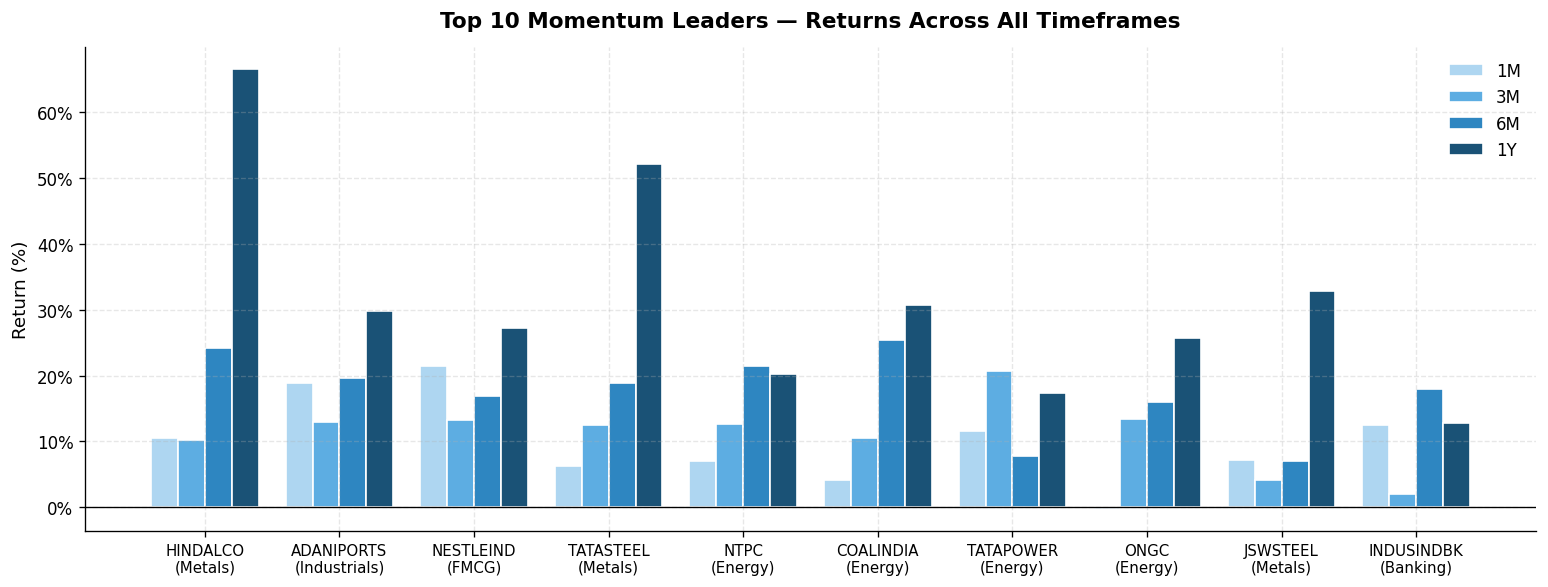


Top 10 Momentum Leaders:
-------------------------------------------------------
  #1  HINDALCO       (Metals      )  Score: 44.6
  #2  ADANIPORTS     (Industrials )  Score: 44.2
  #3  NESTLEIND      (FMCG        )  Score: 43.6
  #4  TATASTEEL      (Metals      )  Score: 42.6
  #5  NTPC           (Energy      )  Score: 41.1
  #6  COALINDIA      (Energy      )  Score: 40.6
  #7  TATAPOWER      (Energy      )  Score: 40.3
  #8  ONGC           (Energy      )  Score: 37.9
  #9  JSWSTEEL       (Metals      )  Score: 37.5
  #10  INDUSINDBK     (Banking     )  Score: 37.0


In [16]:
top10 = returns_df[returns_df['Momentum_Rank'] <= 10].sort_values('Momentum_Rank')

fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(top10))
width = 0.2

bars1 = ax.bar(x - 1.5*width, top10['1M'], width, label='1M', color='#AED6F1', edgecolor='white')
bars2 = ax.bar(x - 0.5*width, top10['3M'], width, label='3M', color='#5DADE2', edgecolor='white')
bars3 = ax.bar(x + 0.5*width, top10['6M'], width, label='6M', color='#2E86C1', edgecolor='white')
bars4 = ax.bar(x + 1.5*width, top10['1Y'], width, label='1Y', color='#1A5276', edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'{s}\n({top10.loc[s,"Sector"]})' for s in top10.index], fontsize=9)
ax.set_ylabel('Return (%)', fontsize=11)
ax.set_title('Top 10 Momentum Leaders — Returns Across All Timeframes', fontsize=13, fontweight='bold', pad=12)
ax.legend(frameon=False, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('top10_momentum.png', bbox_inches='tight')
plt.show()

print('\nTop 10 Momentum Leaders:')
print('-' * 55)
for _, row in top10.iterrows():
    print(f'  #{int(row["Momentum_Rank"])}  {_:<14} ({row["Sector"]:<12})  Score: {row["Composite_Score"]:.1f}')


---
## 📉 Section 7 — Bottom 10 Momentum Laggards

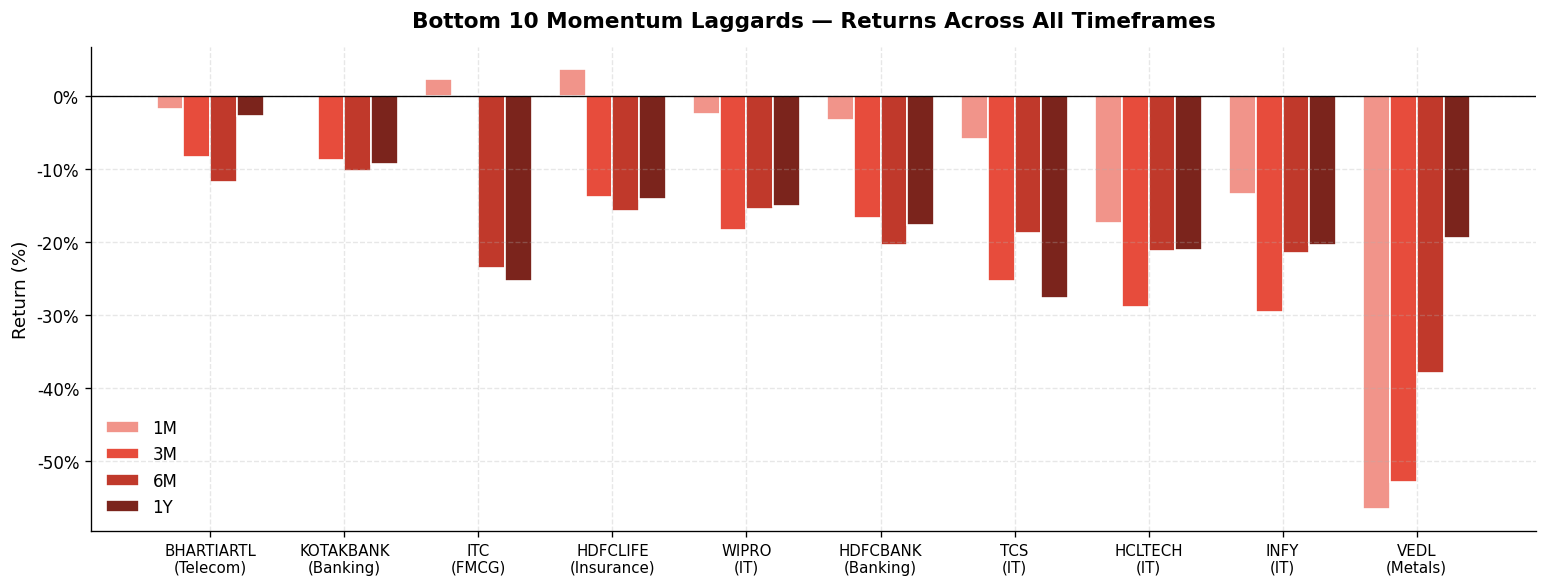


Bottom 10 Momentum Laggards:
-------------------------------------------------------
  #40  BHARTIARTL     (Telecom     )  Score: 12.1
  #41  KOTAKBANK      (Banking     )  Score: 11.9
  #42  ITC            (FMCG        )  Score: 10.4
  #43  HDFCLIFE       (Insurance   )  Score: 9.9
  #44  WIPRO          (IT          )  Score: 7.0
  #45  HDFCBANK       (Banking     )  Score: 6.0
  #46  TCS            (IT          )  Score: 3.7
  #47  HCLTECH        (IT          )  Score: 3.1
  #48  INFY           (IT          )  Score: 3.0
  #49  VEDL           (Metals      )  Score: 2.2


In [17]:
bottom10 = returns_df[returns_df['Momentum_Rank'] > len(returns_df) - 10].sort_values('Momentum_Rank')

fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(bottom10))

bars1 = ax.bar(x - 1.5*width, bottom10['1M'], width, label='1M', color='#F1948A', edgecolor='white')
bars2 = ax.bar(x - 0.5*width, bottom10['3M'], width, label='3M', color='#E74C3C', edgecolor='white')
bars3 = ax.bar(x + 0.5*width, bottom10['6M'], width, label='6M', color='#C0392B', edgecolor='white')
bars4 = ax.bar(x + 1.5*width, bottom10['1Y'], width, label='1Y', color='#7B241C', edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'{s}\n({bottom10.loc[s,"Sector"]})' for s in bottom10.index], fontsize=9)
ax.set_ylabel('Return (%)', fontsize=11)
ax.set_title('Bottom 10 Momentum Laggards — Returns Across All Timeframes', fontsize=13, fontweight='bold', pad=12)
ax.legend(frameon=False, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('bottom10_momentum.png', bbox_inches='tight')
plt.show()

print('\nBottom 10 Momentum Laggards:')
print('-' * 55)
for _, row in bottom10.iterrows():
    print(f'  #{int(row["Momentum_Rank"])}  {_:<14} ({row["Sector"]:<12})  Score: {row["Composite_Score"]:.1f}')


---
## 🗂️ Section 8 — Sector-Level Momentum Heatmap

> This tells you which **sectors** have the best momentum — useful for sector rotation analysis.

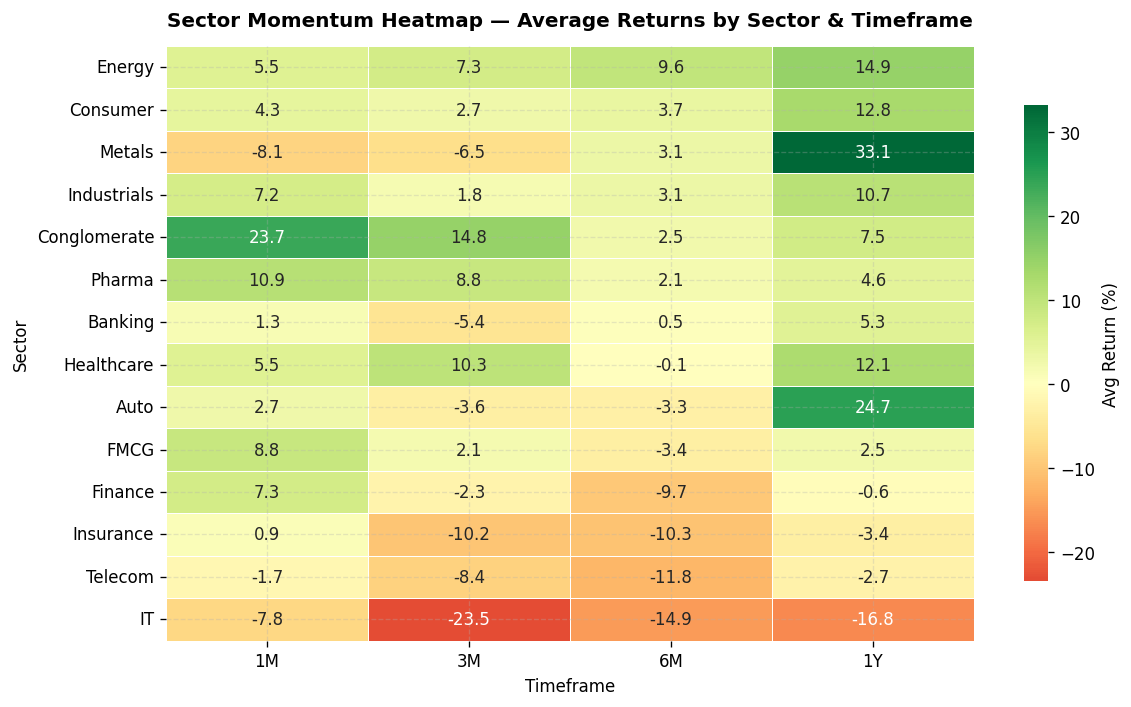


Sector Average Returns (sorted by 6M):
                1M    3M    6M    1Y
Sector                              
Energy         5.5   7.3   9.6  14.9
Consumer       4.3   2.7   3.7  12.8
Metals        -8.1  -6.5   3.1  33.1
Industrials    7.2   1.8   3.1  10.7
Conglomerate  23.7  14.8   2.5   7.5
Pharma        10.9   8.8   2.1   4.6
Banking        1.3  -5.4   0.5   5.3
Healthcare     5.5  10.3  -0.1  12.1
Auto           2.7  -3.6  -3.3  24.7
FMCG           8.8   2.1  -3.4   2.5
Finance        7.3  -2.3  -9.7  -0.6
Insurance      0.9 -10.2 -10.3  -3.4
Telecom       -1.7  -8.4 -11.8  -2.7
IT            -7.8 -23.5 -14.9 -16.8


In [18]:
# Average returns by sector
sector_returns = returns_df.groupby('Sector')[['1M','3M','6M','1Y']].mean().round(1)
sector_returns.sort_values('6M', ascending=False, inplace=True)

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    sector_returns,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Avg Return (%)', 'shrink': 0.8},
    ax=ax
)

ax.set_title('Sector Momentum Heatmap — Average Returns by Sector & Timeframe',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Timeframe', fontsize=10)
ax.set_ylabel('Sector', fontsize=10)

plt.tight_layout()
plt.savefig('sector_heatmap.png', bbox_inches='tight')
plt.show()

print('\nSector Average Returns (sorted by 6M):')
print('=' * 45)
print(sector_returns.to_string())

---
## 📈 Section 9 — Momentum Signal Heatmap (All Stocks)

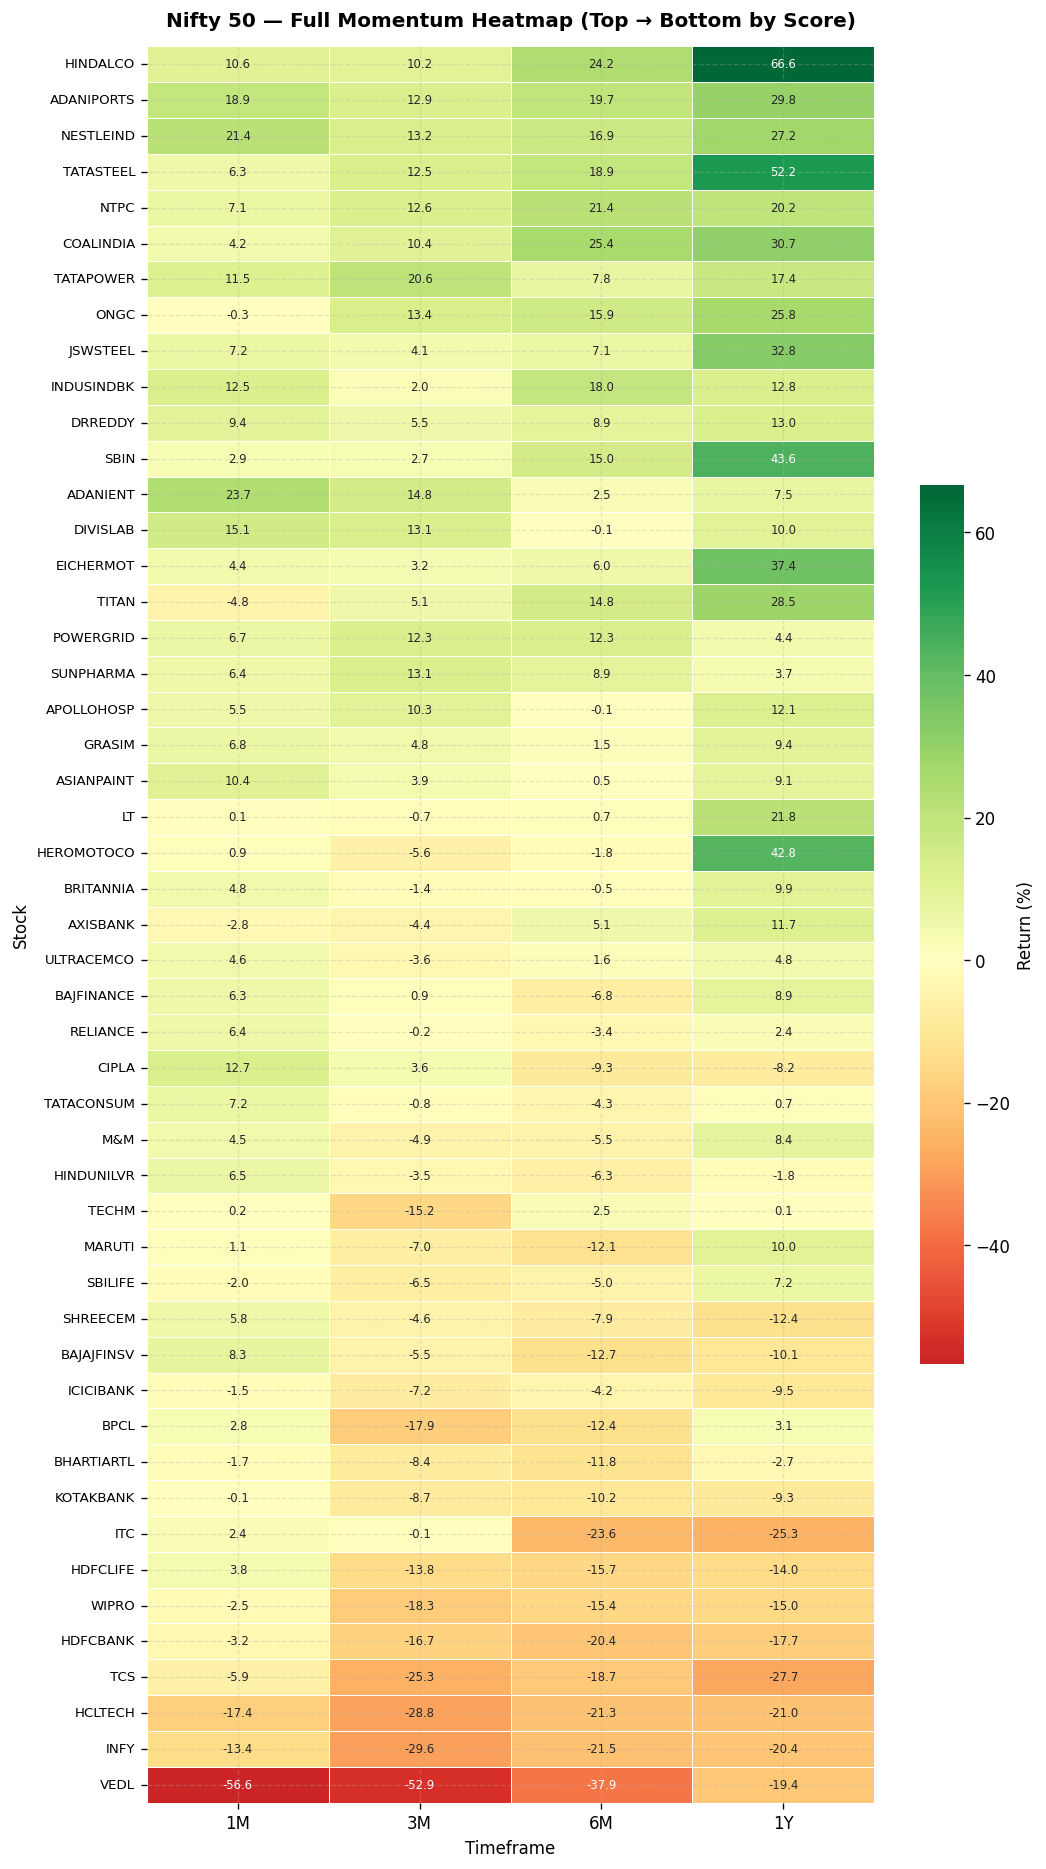

In [19]:
# Heatmap of all stock returns sorted by composite score
heat_data = returns_df[['1M', '3M', '6M', '1Y']].copy()

fig, ax = plt.subplots(figsize=(9, max(10, len(heat_data)*0.32)))

sns.heatmap(
    heat_data,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.3,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Return (%)', 'shrink': 0.5},
    ax=ax
)

ax.set_title('Nifty 50 — Full Momentum Heatmap (Top → Bottom by Score)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Timeframe', fontsize=10)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('full_momentum_heatmap.png', bbox_inches='tight')
plt.show()

---
## 💾 Section 10 — Export Screener to CSV

> Export the full screener as a CSV file — open it in Excel to filter, sort, and analyse rankings across sectors.

In [20]:
export = returns_df[['Sector', 'Price', '1M', '3M', '6M', '1Y', 'Composite_Score', 'Momentum_Rank', 'Signal']].copy()
export.index.name = 'Stock'
export.sort_values('Momentum_Rank', inplace=True)

# Save to CSV
filename = 'nifty50_momentum_screener.csv'
export.to_csv(filename)

print(f'✅ Screener exported to {filename}')
print(f'   {len(export)} stocks | {len(export.columns)} columns')
print()
print('Top 10 by composite score:')
print(export.head(10)[['Sector','1M','3M','6M','1Y','Signal']].to_string())

# Download in Colab
try:
    from google.colab import files
    files.download(filename)
    print(f'\n📥 Download started for {filename}')
except:
    print(f'\n📁 File saved as {filename} in your Colab working directory')

✅ Screener exported to nifty50_momentum_screener.csv
   49 stocks | 9 columns

Top 10 by composite score:
                 Sector     1M     3M     6M     1Y      Signal
Stock                                                          
HINDALCO         Metals  10.56  10.15  24.21  66.59  STRONG BUY
ADANIPORTS  Industrials  18.95  12.93  19.66  29.81  STRONG BUY
NESTLEIND          FMCG  21.39  13.25  16.94  27.22  STRONG BUY
TATASTEEL        Metals   6.34  12.54  18.86  52.19  STRONG BUY
NTPC             Energy   7.08  12.59  21.45  20.22  STRONG BUY
COALINDIA        Energy   4.20  10.45  25.37  30.71  STRONG BUY
TATAPOWER        Energy  11.52  20.64   7.79  17.41  STRONG BUY
ONGC             Energy  -0.26  13.40  15.94  25.76  STRONG BUY
JSWSTEEL         Metals   7.15   4.09   7.09  32.82  STRONG BUY
INDUSINDBK      Banking  12.53   1.98  18.04  12.82         BUY


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Download started for nifty50_momentum_screener.csv


In [22]:
sector_composite_scores = returns_df.groupby('Sector')['Composite_Score'].mean().sort_values(ascending=False)
print('\nAverage Composite Score by Sector (sorted highest to lowest):')
print('=' * 60)
print(sector_composite_scores.to_string())



Average Composite Score by Sector (sorted highest to lowest):
Sector
Conglomerate    36.150000
Energy          32.707143
Pharma          31.912500
Metals          31.750000
Healthcare      30.950000
Consumer        28.900000
Industrials     28.640000
Auto            25.087500
FMCG            24.775000
Banking         21.850000
Finance         19.625000
Insurance       13.675000
Telecom         12.050000
IT               7.040000


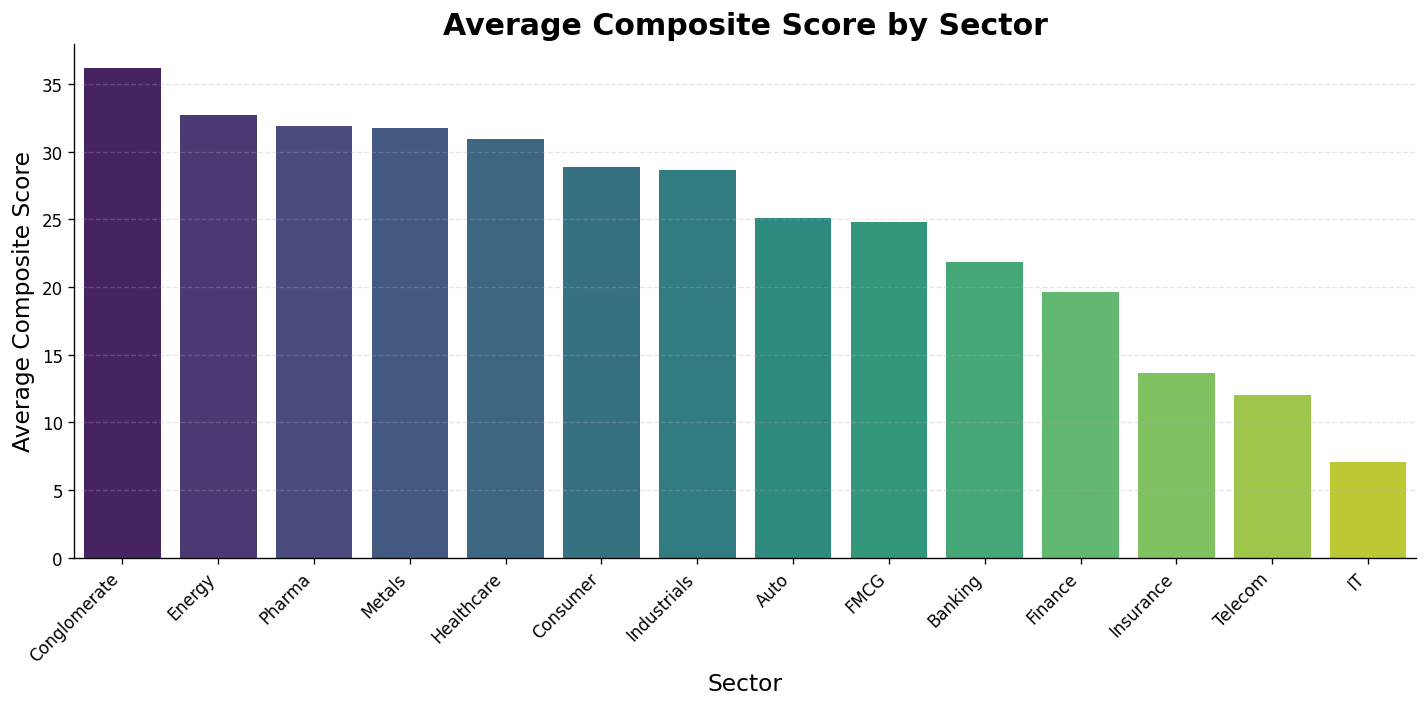

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=sector_composite_scores.index, y=sector_composite_scores.values, palette='viridis')
ax.set_title('Average Composite Score by Sector', fontsize=18, fontweight='bold')
ax.set_xlabel('Sector', fontsize=14)
ax.set_ylabel('Average Composite Score', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 📋 Section 11 — Key Insights & Self-Reflection

After running this screener, answer these questions yourself — these are exactly what an interviewer will ask:

**On sector rotation:**
- Which sector has the strongest momentum across all timeframes?
- Which sector is weakest? What macro reason could explain that?
- Is the same sector leading at 1M and 1Y, or are different sectors leading at different timeframes?

**On individual stocks:**
- Which stock has the highest composite score? Would you buy it based on momentum alone?
- Are any of your Week 1 stocks (HDFC Bank, Reliance, Infosys, TCS, ICICI Bank) in the top 10?
- Do you notice any stocks with strong 1Y momentum but weak 1M — what might that signal?

**On momentum as a strategy:**
- *"Does momentum always work?"* → No. Momentum breaks down in sharp reversals (market crashes, policy changes). It works best in trending markets.
- *"What is the risk of a pure momentum strategy?"* → You buy after stocks have already risen. Crowding risk — too many investors in the same trade.
- *"How does  use momentum?"* → MOSL's 6-month momentum is most widely used — it balances signal strength with avoiding short-term noise.

---
